# Лабораторная работа: Продвинутые способы предварительной обработки данных

**Цель:** Изучение методов обработки пропусков, кодирования категориальных признаков и нормализации числовых признаков.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler

# Загрузка датасета Titanic (содержит пропуски, категории и числа)
df = sns.load_dataset('titanic')
display(df.head())
print(df.isnull().sum())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


### 1. Устранение пропусков в данных
Мы заполним пропуски в колонке 'age' медианным значением, а в колонке 'embark_town' — наиболее частым.

In [2]:
# Импутация для числовых данных (возраст)
imputer_num = SimpleImputer(strategy='median')
df['age'] = imputer_num.fit_transform(df[['age']])

# Импутация для категориальных данных (город посадки)
imputer_cat = SimpleImputer(strategy='most_frequent')
df['embark_town'] = imputer_cat.fit_transform(df[['embark_town']]).ravel()

print("Пропуски после обработки:")
print(df[['age', 'embark_town']].isnull().sum())

Пропуски после обработки:
age            0
embark_town    0
dtype: int64


### 2. Кодирование категориальных признаков
Используем Label Encoding для бинарного признака 'sex' и One-Hot Encoding для 'embark_town'.

In [3]:
# Label Encoding
le = LabelEncoder()
df['sex_encoded'] = le.fit_transform(df['sex'])

# One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False)
embarked_ohe = ohe.fit_transform(df[['embark_town']])
embarked_df = pd.DataFrame(embarked_ohe, columns=ohe.get_feature_names_out(['embark_town']))

df = pd.concat([df, embarked_df], axis=1)
display(df[['sex', 'sex_encoded', 'embark_town'] + list(embarked_df.columns)].head())

,sex,sex_encoded,embark_town,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,male,1,Southampton,0.0,0.0,1.0
1,female,0,Cherbourg,1.0,0.0,0.0
2,female,0,Southampton,0.0,0.0,1.0
3,female,0,Southampton,0.0,0.0,1.0
4,male,1,Southampton,0.0,0.0,1.0


### 3. Нормализация числовых признаков
Применим StandardScaler (Z-оценка) и MinMaxScaler для признака 'fare'.

In [4]:
scaler_std = StandardScaler()
df['fare_std'] = scaler_std.fit_transform(df[['fare']])

scaler_minmax = MinMaxScaler()
df['fare_minmax'] = scaler_minmax.fit_transform(df[['fare']])

display(df[['fare', 'fare_std', 'fare_minmax']].describe())

,fare,fare_std,fare_minmax
count,891.000000,8.910000e+02,891.000000
mean,32.204208,3.987333e-18,0.062858
std,49.693429,1.000562e+00,0.096995
min,0.000000,-6.484217e-01,0.000000
25%,7.910400,-4.891482e-01,0.015440
50%,14.454200,-3.573909e-01,0.028213
75%,31.000000,-2.424635e-02,0.060508
max,512.329200,9.667167e+00,1.000000


## Описание датасета и рекомендации по визуализации

### Описание датасета (Titanic)
Для лабораторной работы использован классический набор данных **Titanic**. Он содержит информацию о пассажирах (возраст, пол, класс билета, стоимость билета и пункт посадки).
* **Категориальные признаки:** `sex`, `embark_town` (город посадки).
* **Числовые признаки:** `age` (возраст), `fare` (стоимость билета).
* **Пропуски:** Присутствовали в колонках `age` и `embark_town`.

### Рекомендуемые графики для визуализации:
1. **Гистограммы распределения:** Для демонстрации нормализации числового признака `fare`. Можно построить график распределения до и после (StandardScaler vs MinMaxScaler).
2. **Тепловая карта (Heatmap):** Для визуализации пропусков в данных до и после этапа очистки (библиотека `missingno` или `sns.heatmap`).
3. **Матрица корреляции:** Чтобы увидеть, как новые закодированные признаки (One-Hot Encoding) коррелируют с целевой переменной `survived`.
4. **Boxplot:** Для сравнения распределения нормализованных данных и выявления выбросов.

### Визуализация результатов «До и После»

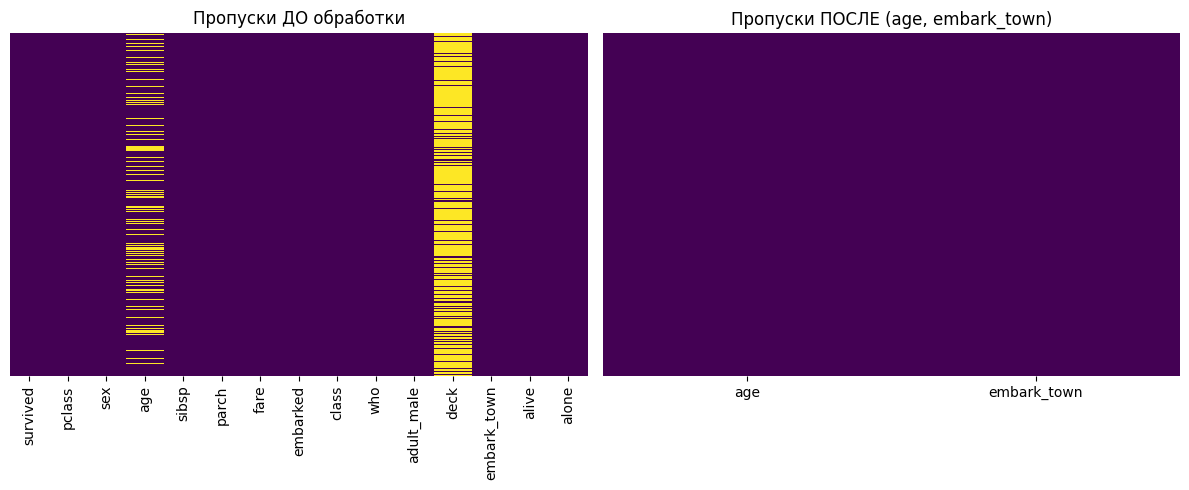

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Визуализация пропусков (сравнение исходного и очищенного датасета)
df_original = sns.load_dataset('titanic')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(df_original.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Пропуски ДО обработки')

sns.heatmap(df[['age', 'embark_town']].isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[1])
axes[1].set_title('Пропуски ПОСЛЕ (age, embark_town)')

plt.tight_layout()
plt.show()

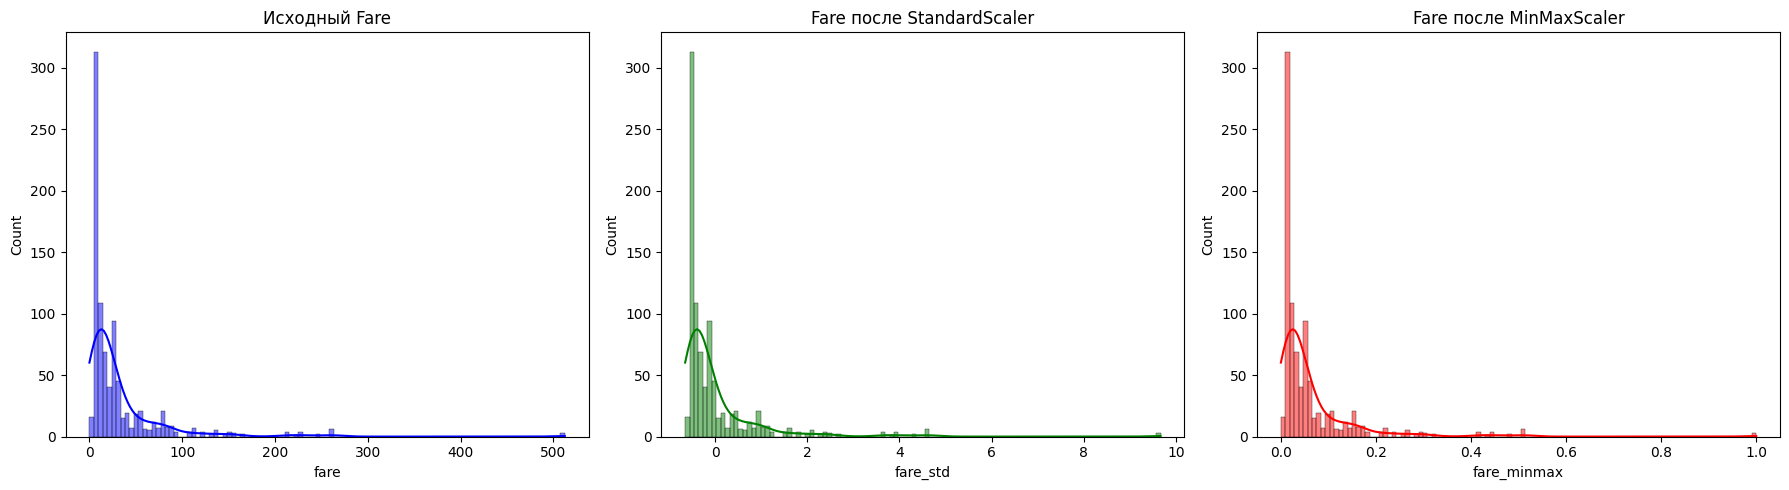

In [6]:
# 2. Визуализация нормализации (распределение Fare)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['fare'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Исходный Fare')

sns.histplot(df['fare_std'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Fare после StandardScaler')

sns.histplot(df['fare_minmax'], kde=True, ax=axes[2], color='red')
axes[2].set_title('Fare после MinMaxScaler')

plt.tight_layout()
plt.show()

### Интерпретация результатов для отчета

**1. Визуализация пропусков (Тепловая карта):**
* **До обработки:** На левом графике отчетливо видны желтые линии в колонках `age` и `embark_town`, что свидетельствует о наличии отсутствующих значений. Это критично, так как большинство алгоритмов машинного обучения не могут работать с пропусками.
* **После обработки:** На правом графике пропуски в выбранных колонках исчезли. Использование медианы для возраста позволило сохранить объем данных, не внося сильных искажений в распределение, а наиболее частое значение для города посадки восстановило категориальную структуру.

**2. Визуализация нормализации (Гистограммы Fare):**
* **Исходный Fare:** Распределение имеет сильный «перекос» вправо (большинство билетов дешевые, но есть очень дорогие). Это может привести к тому, что модель будет придавать избыточный вес признаку с большим масштабом.
* **StandardScaler:** Данные центрированы относительно нуля, а масштаб измеряется в стандартных отклонениях. Это полезно для алгоритмов, чувствительных к масштабу (например, логистическая регрессия или SVM).
* **MinMaxScaler:** Все значения приведены к строгому диапазону от 0 до 1. Это идеальный вариант для нейронных сетей или алгоритмов, основанных на расстояниях (k-NN), так как признак сохраняет свою форму распределения, но ограничивается фиксированными рамками.